In [ ]:
                   ##Attribution###
## Implements a multi‑year LST processing workflow for Dhaka (2014–2024).

## Includes cloud masking, radiometric calibration, spectral indices, emissivity estimation, and single‑channel LST retrieval.

## Adapts the semi‑automatic Landsat time‑series workflow developed by Mohiuddin & Mund (2024) for Phnom Penh.

## Builds on established scientific methods for:

## Radiometric calibration — Nill et al. (2019)

## Single‑channel LST retrieval — Jiménez‑Muñoz et al. (2008)

## Emissivity estimation — Sobrino et al. (2008)

## Fractional vegetation cover (FVC) — Carlson & Ripley (1997)

## Extends the workflow with Dhaka‑specific preprocessing and composite generation.

## All Dhaka‑specific modifications, including additional indices, seasonal
## compositing, and export routines, were implemented by Mahbubul Alam.


In [ ]:
# installing libraries
!pip install geemap --upgrade
!pip install geopandas
!pip install osmnx



In [ ]:
# loading necessary libraries
import os
import sys
import ee
import geemap
import osmnx as ox
import geopandas as gpd
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

In [ ]:
ee.Authenticate()
ee.Initialize(project='ee-sanim')

In [ ]:
# mounting the google dirive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# setting the working directory
os.chdir('/content/drive/MyDrive/ARS/Scientific_Project')
print("Current working directory: {0}".format(os.getcwd()))



Current working directory: /content/drive/MyDrive/ARS/Scientific_Project


In [ ]:
# export the dataframe to a CSV file
df.to_csv('lsttimeseries.csv', index=False)

# Function 6: Loading the csv/txt file
def load_csv(filepath):
    data =  []
    col = []
    checkcol = False
    with open(filepath) as f:
        for val in f.readlines():
            val = val.replace("\n","")
            val = val.split(',')
            if checkcol is False:
                col = val
                checkcol = True
            else:
                data.append(val)
    df = pd.DataFrame(data=data, columns=col)

    return df

# Loading the data
myData = load_csv('lsttimeseries.csv')
df = myData
print(df.head())

In [ ]:
display(df_filtered.describe())

In [ ]:
display(df_filtered.head())

In [ ]:
# mean LST calendar heatmap
alt.Chart(df).mark_rect().encode(
    x='Year:O',
    y='Month:O',
    color=alt.Color(
        'MeanLST:Q', title = 'Mean LST (in °C)', scale=alt.Scale(scheme='viridis', domain=(20,45 ))),
    tooltip=[
        alt.Tooltip('Year:O', title='Year'),
        alt.Tooltip('Month:O', title='Month'),
        alt.Tooltip('MeanLST:Q', title='LST')
    ]).properties(width=600, height=300)


alt.Chart(...)

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')

print(df['NAME_3'].unique())
print("Number of zones:", df['NAME_3'].nunique())


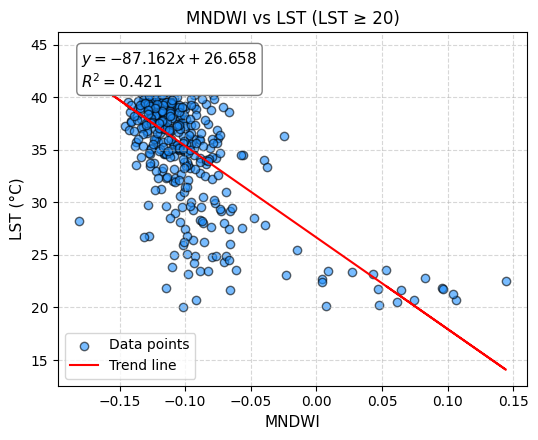

In [ ]:


# MNDWI vs LST (LST ≥ 20)

# Filter valid data and apply LST threshol
clean_data = df3.dropna(subset=['MNDWI', 'LST'])
clean_data = clean_data[clean_data['LST'] >= 20]

x = clean_data['MNDWI']
y = clean_data['LST']

# Linear regression
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
y_hat = p(x)
r2 = r2_score(y, y_hat)

# Plot
plt.figure(figsize=(5.5, 4.5))
plt.scatter(x, y, color='dodgerblue', alpha=0.6, edgecolor='k', label='Data points')
plt.plot(x, y_hat, "r-", lw=1.5, label='Trend line')

# Regression annotation
eq_text = (
    f"$y = {z[0]:.3f}x {z[1]:+0.3f}$\n"
    f"$R^2 = {r2:.3f}$"
)

plt.text(
    0.05, 0.95, eq_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3')
)

# Labels and layout
plt.title('MNDWI vs LST (LST ≥ 20)', fontsize=12)
plt.xlabel('MNDWI', fontsize=11)
plt.ylabel('LST (°C)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


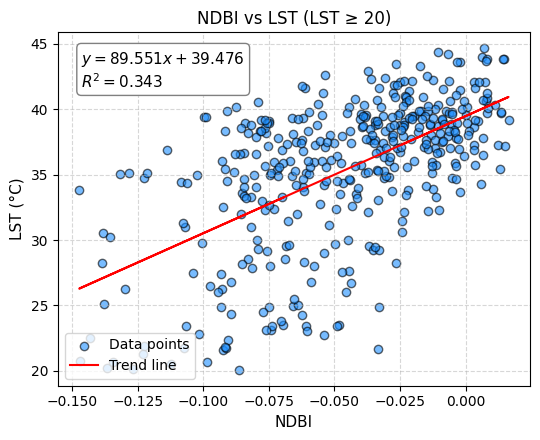

In [ ]:
# NDBI vs LST (LST ≥ 20)

# Convert columns to numeric
df3["NDBI"] = pd.to_numeric(df3["NDBI"], errors='coerce')
df3["LST"] = pd.to_numeric(df3["LST"], errors='coerce')

# Filter valid data and apply LST threshold
clean_data = df3.dropna(subset=['NDBI', 'LST'])
clean_data = clean_data[clean_data['LST'] >= 20]

x = clean_data['NDBI']
y = clean_data['LST']

# Linear regression
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
y_hat = p(x)
r2 = r2_score(y, y_hat)

# Plot
plt.figure(figsize=(5.5, 4.5))
plt.scatter(x, y, color='dodgerblue', alpha=0.6, edgecolor='k', label='Data points')
plt.plot(x, y_hat, "r-", lw=1.5, label='Trend line')

# Regression annotation
eq_text = (
    f"$y = {z[0]:.3f}x {z[1]:+0.3f}$\n"
    f"$R^2 = {r2:.3f}$"
)

plt.text(
    0.05, 0.95, eq_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3')
)

# Labels and layout
plt.title('NDBI vs LST (LST ≥ 20)', fontsize=12)
plt.xlabel('NDBI', fontsize=11)
plt.ylabel('LST (°C)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


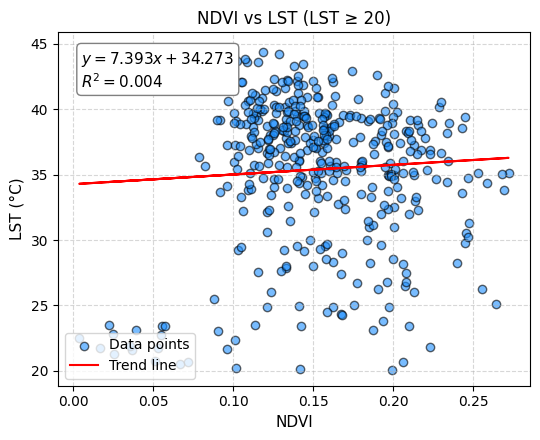

In [ ]:
# NDVI vs LST (LST ≥ 20)
# Convert columns to numeric
df3["NDVI"] = pd.to_numeric(df3["NDVI"], errors='coerce')
df3["LST"] = pd.to_numeric(df3["LST"], errors='coerce')

# Filter valid data and apply LST threshold
clean_data = df3.dropna(subset=['NDVI', 'LST'])
clean_data = clean_data[clean_data['LST'] >= 20]

x = clean_data['NDVI']
y = clean_data['LST']

# Linear regression
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
y_hat = p(x)
r2 = r2_score(y, y_hat)

# Plot
plt.figure(figsize=(5.5, 4.5))
plt.scatter(x, y, color='dodgerblue', alpha=0.6, edgecolor='k', label='Data points')
plt.plot(x, y_hat, "r-", lw=1.5, label='Trend line')

# Regression annotation
eq_text = (
    f"$y = {z[0]:.3f}x {z[1]:+0.3f}$\n"
    f"$R^2 = {r2:.3f}$"
)

plt.text(
    0.05, 0.95, eq_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3')
)

# Labels and layout
plt.title('NDVI vs LST (LST ≥ 20)', fontsize=12)
plt.xlabel('NDVI', fontsize=11)
plt.ylabel('LST (°C)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


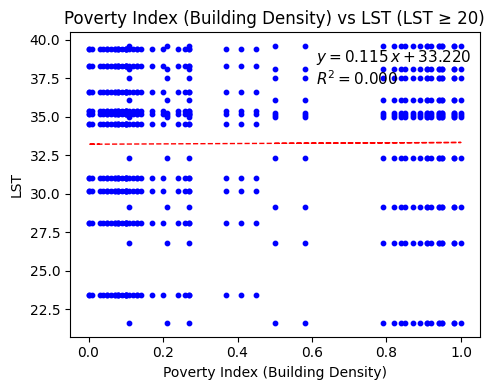

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

# Re-load df3 and poverty data, and merge to ensure 'poverty_2017' is present
# This block is re-added to ensure independence and robustness for this cell's execution.
df3 = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
poverty = pd.read_csv('/content/drive/MyDrive/Dhaka_Poverty_2017.csv')
poverty.rename(columns={'NB_BUDENS': 'poverty_2017'}, inplace=True)
df3 = df3.merge(poverty[['AL3_NAMEF', 'poverty_2017']], left_on='NAME_3', right_on='AL3_NAMEF', how='left')

# Ensure LST and poverty_2017 columns are numeric
df3["LST"] = pd.to_numeric(df3["LST"], errors='coerce')
df3["poverty_2017"] = pd.to_numeric(df3["poverty_2017"], errors='coerce')


# Remove missing values for 'poverty_2017' and 'LST'
clean_data_bd = df3.dropna(subset=['poverty_2017', 'LST'])

# Apply LST threshold
clean_data_bd = clean_data_bd[clean_data_bd['LST'] >= 20]

x = clean_data_bd['poverty_2017']
y = clean_data_bd['LST']

plt.figure(figsize=(5, 4))
plt.scatter(x, y, color='blue', s=10)

# Linear regression
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
y_hat = p(x)

plt.plot(x, y_hat, "r--", lw=1)

# Regression equation + R²
text = f"""$y={z[0]:0.3f}\,x{z[1]:+0.3f}$
$R^2 = {r2_score(y, y_hat):0.3f}$"""

plt.gca().text(
    0.60, 0.95, text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top'
)

plt.title('Poverty Index (Building Density) vs LST (LST ≥ 20)')
plt.xlabel('Poverty Index (Building Density)')
plt.ylabel('LST')

plt.tight_layout()
plt.show()

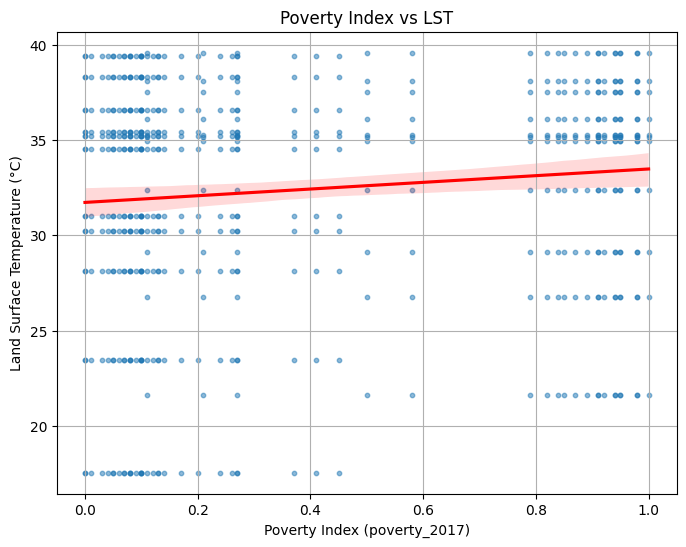

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure df3 has poverty_2017 and LST columns
# (These operations are expected to have been run in prior cells successfully)
# df3 = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
# poverty = pd.read_csv('/content/drive/MyDrive/Dhaka_Poverty_2017.csv')
# poverty.rename(columns={'NB_BUDENS': 'poverty_2017'}, inplace=True)
# df3 = df3.merge(poverty[['AL3_NAMEF', 'poverty_2017']], left_on='NAME_3', right_on='AL3_NAMEF', how='left')

# Drop rows with NaN values in 'poverty_2017' or 'LST' to ensure plotting works
df_plot_cleaned = df3.dropna(subset=['poverty_2017', 'LST'])

plt.figure(figsize=(8,6))

sns.regplot(
    data=df_plot_cleaned,
    x='poverty_2017',
    y='LST',
    scatter_kws={'s':10, 'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title('Poverty Index vs LST')
plt.xlabel('Poverty Index (poverty_2017)')
plt.ylabel('Land Surface Temperature (°C)')
plt.grid(True)
plt.show()

In [ ]:
# spatial data points
df = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
total_points = len(df)
print(total_points)

451


In [ ]:
 lst_cols = [col for col in df3.columns if 'LST_' in col]  # auto-detect yearly LST columns

# df3['mean_LST_2014_2024'] = df3[lst_cols].mean(axis=1)


In [ ]:
df3 = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
df3.head()
df3.columns


In [ ]:
df3.columns


In [ ]:
import pandas as pd

poverty = pd.read_csv('/content/drive/MyDrive/Dhaka_Poverty_2017.csv')
poverty.head()
poverty.columns


In [ ]:
poverty.rename(columns={'NB_BUDENS': 'poverty_2017'}, inplace=True)


In [ ]:
df3 = df3.merge(poverty[['AL3_NAMEF', 'poverty_2017']], left_on='NAME_3', right_on='AL3_NAMEF', how='left')

In [ ]:
mean_lst = df3.groupby('NAME_3')['LST'].mean().reset_index()
mean_lst.rename(columns={'LST': 'mean_LST_2014_2024'}, inplace=True)

df3 = df3.merge(mean_lst, on='NAME_3', how='left')


In [ ]:
df_plot = df3[['NAME_3', 'poverty_2017', 'mean_LST_2014_2024']].drop_duplicates()
df_plot.head()


⚠ Merge mismatches: 429 wards did not match poverty data


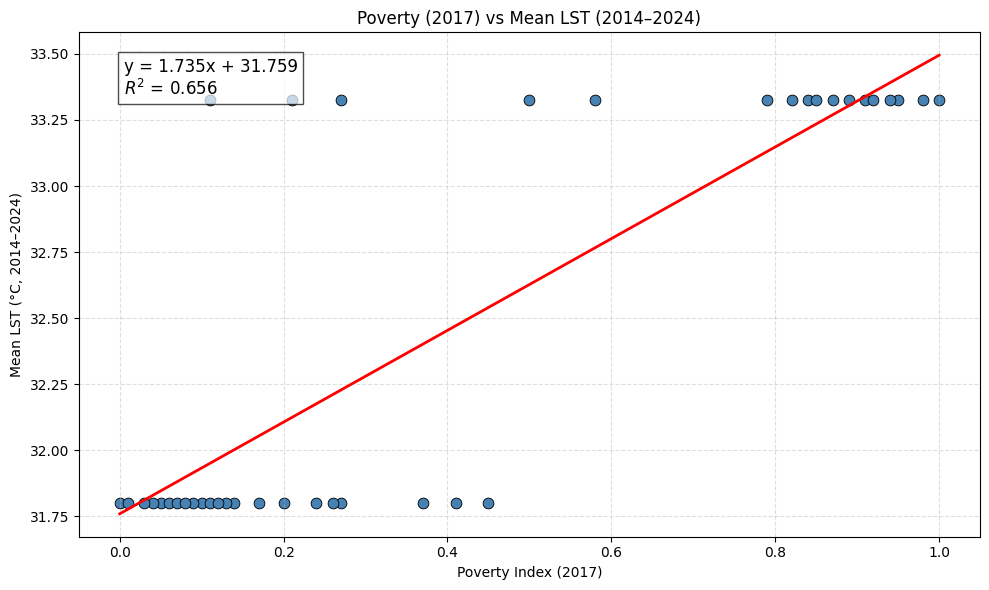

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------
# Load datasets
# ---------------------------------------------------------
df3 = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
poverty = pd.read_csv('/content/drive/MyDrive/Dhaka_Poverty_2017.csv')

# ---------------------------------------------------------
# AUTO-DETECT POVERTY COLUMN
# ---------------------------------------------------------
possible_poverty_cols = ['NB_BUDENS','poverty','poverty_index','Poverty','POVERTY','poverty_2017']
poverty_col_detected = None

for col in poverty.columns:
    if col in possible_poverty_cols:
        poverty_col_detected = col
        break

if poverty_col_detected is None:
    raise ValueError("No poverty column found. Check poverty CSV.")

poverty.rename(columns={poverty_col_detected: 'poverty_2017'}, inplace=True)

# ---------------------------------------------------------
# AUTO-DETECT NAME COLUMN FOR MERGE
# ---------------------------------------------------------
possible_name_cols = ['NAME_3','AL3_NAMEF','Ward','WARD','NAME','NAME_2','NAME_1']
poverty_name_col = None

for col in poverty.columns:
    if col in possible_name_cols:
        poverty_name_col = col
        break

if poverty_name_col is None:
    raise ValueError("No matching name column found in poverty CSV.")

# ---------------------------------------------------------
# MERGE POVERTY WITH df3
# ---------------------------------------------------------
df3 = df3.merge(
    poverty[[poverty_name_col, 'poverty_2017']],
    left_on='NAME_3',
    right_on=poverty_name_col,
    how='left'
)

# ---------------------------------------------------------
# CHECK MERGE MISMATCHES
# ---------------------------------------------------------
missing = df3['poverty_2017'].isna().sum()
print(f"⚠ Merge mismatches: {missing} wards did not match poverty data")

# ---------------------------------------------------------
# COMPUTE MEAN LST (2014–2024)
# ---------------------------------------------------------
mean_lst = df3.groupby('NAME_3')['LST'].mean().reset_index()
mean_lst.rename(columns={'LST': 'mean_LST_2014_2024'}, inplace=True)

df3 = df3.merge(mean_lst, on='NAME_3', how='left')

# ---------------------------------------------------------
# FINAL CLEAN DATASET
# ---------------------------------------------------------
df_plot = df3[['NAME_3','poverty_2017','mean_LST_2014_2024']].drop_duplicates()
df_plot = df_plot.dropna()

# ---------------------------------------------------------
# REGRESSION MODEL
# ---------------------------------------------------------
X = df_plot[['poverty_2017']].values
y = df_plot['mean_LST_2014_2024'].values

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

x_range = np.linspace(df_plot['poverty_2017'].min(), df_plot['poverty_2017'].max(), 100)
y_pred = model.predict(x_range.reshape(-1, 1))

# ---------------------------------------------------------
# PLOT 1 — POVERTY vs MEAN LST
# ---------------------------------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_plot, x='poverty_2017', y='mean_LST_2014_2024',
                color='steelblue', s=60, edgecolor='black')
plt.plot(x_range, y_pred, color='red', linewidth=2)

plt.title("Poverty (2017) vs Mean LST (2014–2024)")
plt.xlabel("Poverty Index (2017)")
plt.ylabel("Mean LST (°C, 2014–2024)")

plt.text(0.05, 0.95,
         f"y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r2:.3f}",
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


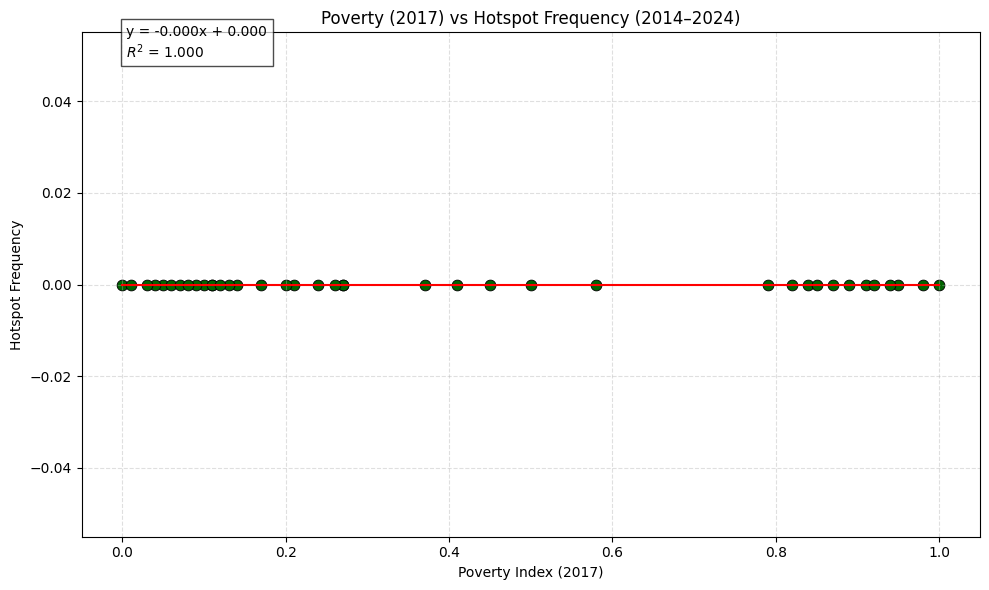

In [ ]:
# Calculate hotspot_freq and merge into df3 if not already present
# Compute 95th percentile threshold
threshold = df3['LST'].quantile(0.95)

# Mark hotspot rows
df3['is_hotspot'] = (df3['LST'] >= threshold).astype(int)

# Compute hotspot frequency per ward
hotspot_freq_df = df3.groupby('NAME_3')['is_hotspot'].sum().reset_index()
hotspot_freq_df.rename(columns={'is_hotspot': 'hotspot_freq'}, inplace=True)

# Merge hotspot_freq into df3
df3 = df3.merge(hotspot_freq_df, on='NAME_3', how='left')

df_hot = df3[['NAME_3','poverty_2017','hotspot_freq']].drop_duplicates().dropna()

X = df_hot[['poverty_2017']]
y = df_hot['hotspot_freq']

model = LinearRegression().fit(X, y)
slope, intercept, r2 = model.coef_[0], model.intercept_, model.score(X, y)

x_range = np.linspace(df_hot['poverty_2017'].min(), df_hot['poverty_2017'].max(), 100)
y_pred = model.predict(x_range.reshape(-1,1))

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_hot, x='poverty_2017', y='hotspot_freq',
                color='darkgreen', s=60, edgecolor='black')
plt.plot(x_range, y_pred, color='red')

plt.title("Poverty (2017) vs Hotspot Frequency (2014–2024)")
plt.xlabel("Poverty Index (2017)")
plt.ylabel("Hotspot Frequency")

plt.text(0.05, 0.95,
         f"y = {slope:.3f}x + {intercept:.3f}\n$R^2$ = {r2:.3f}",
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.7))

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
threshold = df3['LST'].quantile(0.95)


In [ ]:
df3['is_hotspot'] = (df3['LST'] >= threshold).astype(int)


In [ ]:
hotspot_freq = df3.groupby('NAME_3')['is_hotspot'].sum().reset_index()
hotspot_freq.rename(columns={'is_hotspot': 'hotspot_freq'}, inplace=True)


In [ ]:
df3 = df3.merge(hotspot_freq, on='NAME_3', how='left')


In [ ]:
# Compute 95th percentile threshold
threshold = df3['LST'].quantile(0.95)

# Mark hotspot rows
df3['is_hotspot'] = (df3['LST'] >= threshold).astype(int)

# Compute hotspot frequency per ward
hotspot_freq_df = df3.groupby('NAME_3')['is_hotspot'].sum().reset_index()
hotspot_freq_df.rename(columns={'is_hotspot': 'hotspot_freq'}, inplace=True)

# Merge hotspot_freq into df3
df3 = df3.merge(hotspot_freq_df, on='NAME_3', how='left')

df_hot = df3[['NAME_3','poverty_2017','hotspot_freq']].drop_duplicates().dropna()

In [ ]:
# Compute 95th percentile threshold
threshold = df3['LST'].quantile(0.95)

# Mark hotspot rows
df3['is_hotspot'] = (df3['LST'] >= threshold).astype(int)

# Compute hotspot frequency per ward
hotspot_freq = df3.groupby('NAME_3')['is_hotspot'].sum().reset_index()
hotspot_freq.rename(columns={'is_hotspot': 'hotspot_freq'}, inplace=True)

# Merge into df3
df3 = df3.merge(hotspot_freq, on='NAME_3', how='left')


In [ ]:
from scipy.stats import theilslopes

trend_list = []

for ward, group in df3.groupby('NAME_3'):
    years = group['year'].values
    lst_vals = group['LST'].values

    slope, intercept, _, _ = theilslopes(lst_vals, years)

    trend_list.append([ward, slope])

trend_df = pd.DataFrame(trend_list, columns=['NAME_3', 'trend_slope'])

df3 = df3.merge(trend_df, on='NAME_3', how='left')


In [ ]:
# This operation is redundant as 'mean_LST_2014_2024' is already in df3 from a previous cell.
# mean_lst = df3.groupby('NAME_3')['LST'].mean().reset_index()
# mean_lst.rename(columns={'LST': 'mean_LST_2014_2024'}, inplace=True)
# df3 = df3.merge(mean_lst, on='NAME_3', how='left')

In [ ]:
import pandas as pd # Ensure pandas is imported if not globally available
import numpy as np # Import numpy for np.nan if needed

# This entire block for calculating and merging mean_lst is redundant
# as it should have been done in Y7ndQquVy9L8
# mean_lst = df3.groupby('NAME_3')['LST'].mean().reset_index()
# mean_lst.rename(columns={'LST': 'mean_LST_2014_2024'}, inplace=True)
# df3 = df3.merge(mean_lst, on='NAME_3', how='left')

# The df3 should already contain 'poverty_2017', 'mean_LST_2014_2024', 'hotspot_freq', and 'trend_slope'
# from previous cells (UfS5P-4zyqpT, Y7ndQquVy9L8, JsBE8ien0h05, nEqKb5bW1bwB).

# REMOVED .dropna() to preserve all zones, as per previous fix attempt
df_zone = df3[['NAME_3','poverty_2017','mean_LST_2014_2024',
               'hotspot_freq','trend_slope']].drop_duplicates()

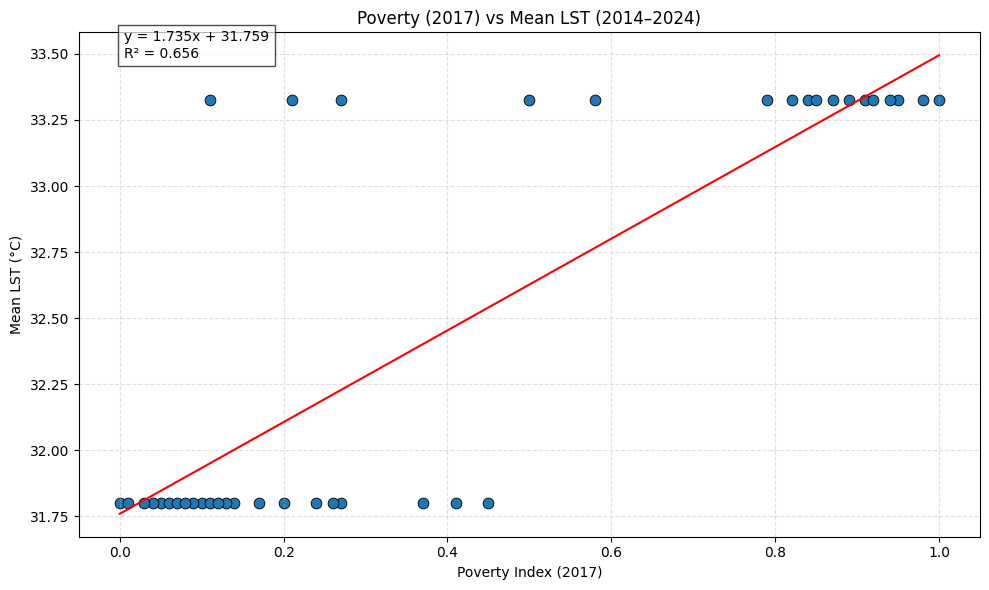

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Create a cleaned DataFrame for the regression, dropping rows with NaNs in relevant columns
df_cleaned_for_regression = df_zone.dropna(subset=['poverty_2017', 'mean_LST_2014_2024'])

X = df_cleaned_for_regression[['poverty_2017']]
y = df_cleaned_for_regression['mean_LST_2014_2024']

model = LinearRegression().fit(X, y)
slope, intercept, r2 = model.coef_[0], model.intercept_, model.score(X, y)

x_range = np.linspace(X.min(), X.max(), 100)
y_pred = model.predict(x_range.reshape(-1,1))

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_cleaned_for_regression, x='poverty_2017', y='mean_LST_2014_2024',
                s=60, edgecolor='black')
plt.plot(x_range, y_pred, color='red')

plt.title("Poverty (2017) vs Mean LST (2014–2024)")
plt.xlabel("Poverty Index (2017)")
plt.ylabel("Mean LST (°C)")

plt.text(0.05, 0.95,
         f"y = {slope:.3f}x + {intercept:.3f}\nR² = {r2:.3f}",
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.7))

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

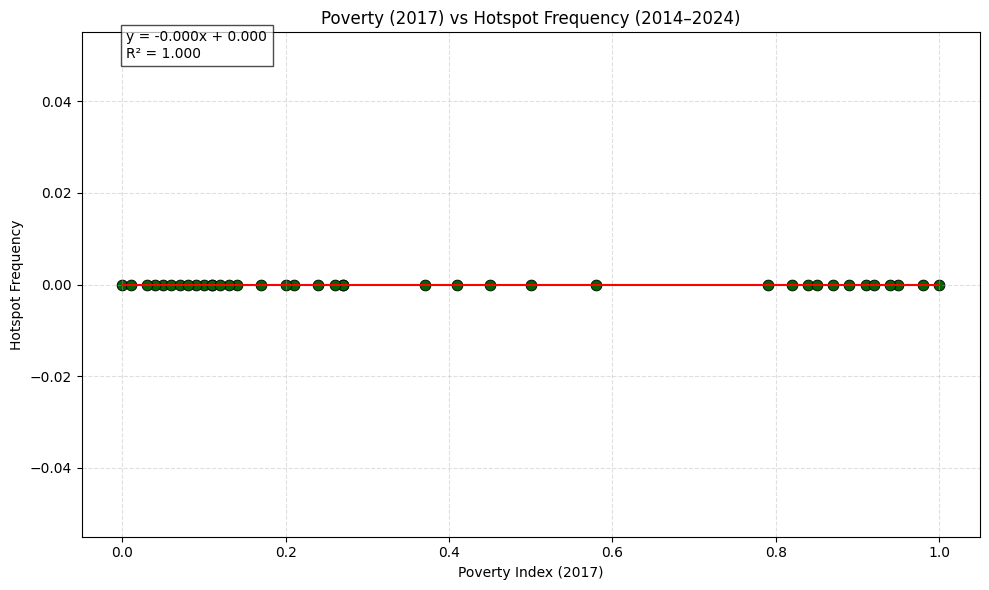

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# Create a cleaned DataFrame for the regression, dropping rows with NaNs in relevant columns
df_cleaned_for_regression = df_zone.dropna(subset=['poverty_2017', 'hotspot_freq'])

X = df_cleaned_for_regression[['poverty_2017']]
y = df_cleaned_for_regression['hotspot_freq']

model = LinearRegression().fit(X, y)
slope, intercept, r2 = model.coef_[0], model.intercept_, model.score(X, y)

x_range = np.linspace(X.min(), X.max(), 100)
y_pred = model.predict(x_range.reshape(-1,1))

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_cleaned_for_regression, x='poverty_2017', y='hotspot_freq',
                s=60, edgecolor='black', color='darkgreen')
plt.plot(x_range, y_pred, color='red')

plt.title("Poverty (2017) vs Hotspot Frequency (2014–2024)")
plt.xlabel("Poverty Index (2017)")
plt.ylabel("Hotspot Frequency")

plt.text(0.05, 0.95,
         f"y = {slope:.3f}x + {intercept:.3f}\nR² = {r2:.3f}",
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.7))

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

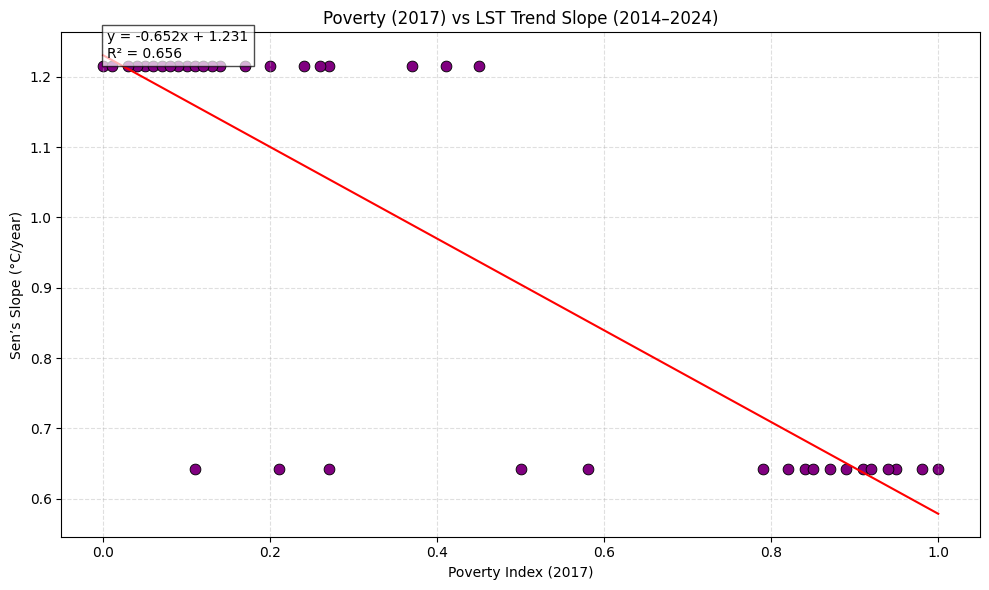

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# Create a cleaned DataFrame for the regression, dropping rows with NaNs in relevant columns
df_cleaned_for_regression = df_zone.dropna(subset=['poverty_2017', 'trend_slope'])

X = df_cleaned_for_regression[['poverty_2017']]
y = df_cleaned_for_regression['trend_slope']

model = LinearRegression().fit(X, y)
slope, intercept, r2 = model.coef_[0], model.intercept_, model.score(X, y)

x_range = np.linspace(X.min(), X.max(), 100)
y_pred = model.predict(x_range.reshape(-1,1))

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_cleaned_for_regression, x='poverty_2017', y='trend_slope',
                s=60, edgecolor='black', color='purple')
plt.plot(x_range, y_pred, color='red')

plt.title("Poverty (2017) vs LST Trend Slope (2014–2024)")
plt.xlabel("Poverty Index (2017)")
plt.ylabel("Sen’s Slope (°C/year)")

plt.text(0.05, 0.95,
         f"y = {slope:.3f}x + {intercept:.3f}\nR² = {r2:.3f}",
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.7))

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

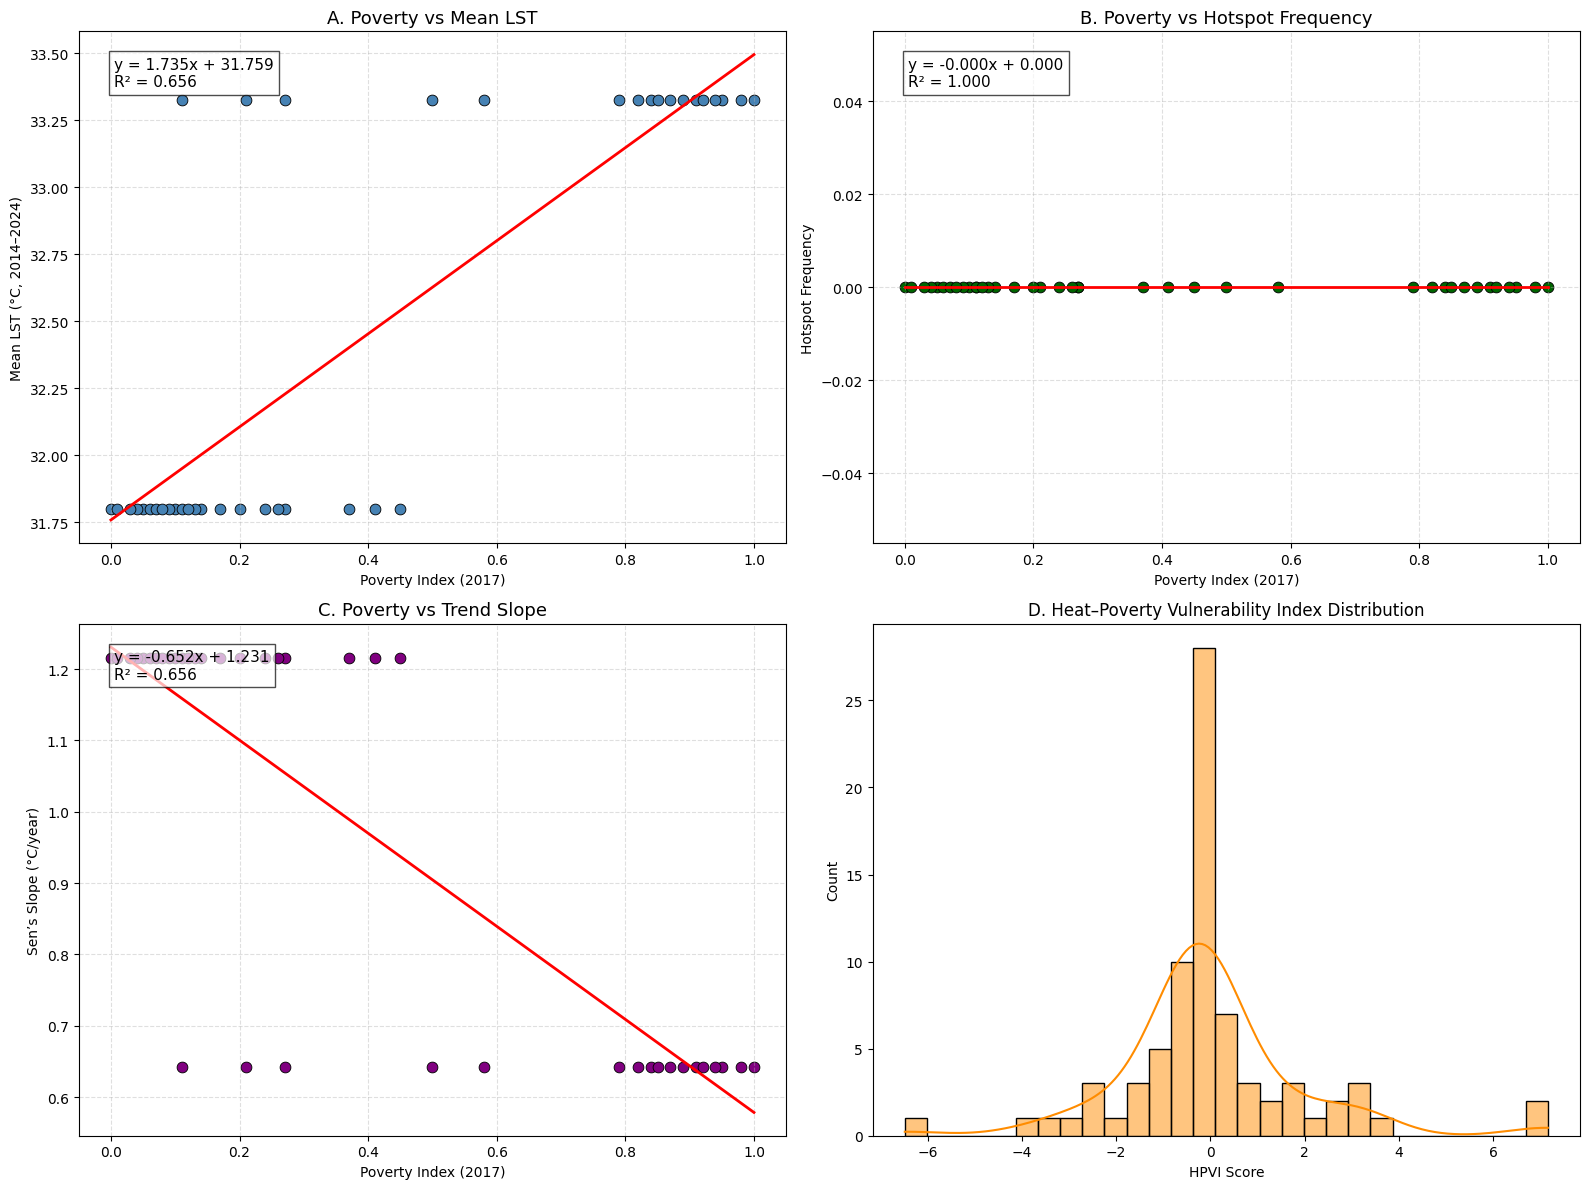

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
from scipy.stats import zscore, theilslopes # Import zscore and theilslopes
import pandas as pd # Ensure pandas is imported

# --- Reconstruct df_zone with all necessary metrics within this cell ---
# This ensures df_zone has 'poverty_2017', 'mean_LST_2014_2024', 'hotspot_freq', and 'trend_slope'

# 1. Load df3 and poverty dataframes
df3 = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
poverty = pd.read_csv('/content/drive/MyDrive/Dhaka_Poverty_2017.csv')

# 2. Rename 'NB_BUDENS' to 'poverty_2017' in poverty df
poverty.rename(columns={'NB_BUDENS': 'poverty_2017'}, inplace=True)

# 3. Merge poverty into df3
df3 = df3.merge(poverty[['AL3_NAMEF', 'poverty_2017']], left_on='NAME_3', right_on='AL3_NAMEF', how='left')

# Ensure LST column is numeric before calculations
df3['LST'] = pd.to_numeric(df3['LST'], errors='coerce')

# 4. Calculate mean_LST_2014_2024 and merge into df3
mean_lst = df3.groupby('NAME_3')['LST'].mean().reset_index()
mean_lst.rename(columns={'LST': 'mean_LST_2014_2024'}, inplace=True)
df3 = df3.merge(mean_lst, on='NAME_3', how='left')

# 5. Calculate hotspot_freq and merge into df3
threshold_hotspot = df3['LST'].quantile(0.95)
df3['is_hotspot'] = (df3['LST'] >= threshold_hotspot).astype(int)
hotspot_freq = df3.groupby('NAME_3')['is_hotspot'].sum().reset_index()
hotspot_freq.rename(columns={'is_hotspot': 'hotspot_freq'}, inplace=True)
df3 = df3.merge(hotspot_freq, on='NAME_3', how='left')

# 6. Calculate trend_slope using Theil-Sen and merge into df3
trend_list = []
for ward, group in df3.groupby('NAME_3'):
    years = group['year'].values
    lst_vals = group['LST'].values
    if len(years) > 1:
        slope, intercept, _, _ = theilslopes(lst_vals, years)
        trend_list.append([ward, slope])
    else:
        trend_list.append([ward, np.nan]) # Handle single-point wards with NaN
trend_df = pd.DataFrame(trend_list, columns=['NAME_3', 'trend_slope'])
df3 = df3.merge(trend_df, on='NAME_3', how='left')

# 7. Create df_zone with unique aggregated data per ward
df_zone = df3[['NAME_3', 'poverty_2017', 'mean_LST_2014_2024',
               'hotspot_freq', 'trend_slope']].drop_duplicates().copy()

# --- Now proceed with HPVI calculation on the correctly structured df_zone ---

# Ensure all HPVI component columns are numeric for zscore calculation
df_zone['poverty_2017'] = pd.to_numeric(df_zone['poverty_2017'], errors='coerce')
df_zone['mean_LST_2014_2024'] = pd.to_numeric(df_zone['mean_LST_2014_2024'], errors='coerce')
df_zone['hotspot_freq'] = pd.to_numeric(df_zone['hotspot_freq'], errors='coerce')
df_zone['trend_slope'] = pd.to_numeric(df_zone['trend_slope'], errors='coerce')

# Calculate Z-scores (only for non-NaN values)
df_zone['z_poverty'] = df_zone['poverty_2017'].pipe(lambda x: (x - x.mean()) / x.std())
df_zone['z_lst'] = df_zone['mean_LST_2014_2024'].pipe(lambda x: (x - x.mean()) / x.std())
df_zone['z_hotspot'] = df_zone['hotspot_freq'].pipe(lambda x: (x - x.mean()) / x.std())
df_zone['z_trend'] = df_zone['trend_slope'].pipe(lambda x: (x - x.mean()) / x.std())

# Only calculate HPVI where all z-scores are available
df_zone['HPVI'] = (df_zone['z_poverty'].fillna(0) * 0.5 + # Example weights, adjust as needed
                   df_zone['z_lst'].fillna(0) * 1.0 +
                   df_zone['z_hotspot'].fillna(0) * 1.5 +
                   df_zone['z_trend'].fillna(0) * 1.5)

df_zone['HPVI_class'] = pd.cut(
    df_zone['HPVI'],
    bins=[-np.inf, -0.5, 0.5, 1.5, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

# Helper function for regression scatter plots
def regression_plot(ax, x_col, y_col, xlabel, ylabel, title, color):
    # Drop NaNs specific to the x and y for the regression plot only
    plot_data = df_zone.dropna(subset=[x_col, y_col])

    X = plot_data[[x_col]].values
    Y = plot_data[y_col].values

    model = LinearRegression().fit(X, Y)
    slope, intercept, r2 = model.coef_[0], model.intercept_, model.score(X, Y)

    x_range = np.linspace(plot_data[x_col].min(), plot_data[x_col].max(), 100)
    y_pred = model.predict(x_range.reshape(-1, 1))

    sns.scatterplot(data=plot_data, x=x_col, y=y_col, ax=ax,
                    s=60, edgecolor='black', color=color)
    ax.plot(x_range, y_pred, color='red', linewidth=2)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.text(0.05, 0.95,
            f"y = {slope:.3f}x + {intercept:.3f}\nR² = {r2:.3f}",
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.7))
    ax.grid(True, linestyle='--', alpha=0.4)

# Create figure and axes for the plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Panel A
regression_plot(
    axes[0],
    x_col='poverty_2017',
    y_col='mean_LST_2014_2024',
    xlabel="Poverty Index (2017)",
    ylabel="Mean LST (°C, 2014–2024)",
    title="A. Poverty vs Mean LST",
    color='steelblue'
)

# Panel B
regression_plot(
    axes[1],
    x_col='poverty_2017',
    y_col='hotspot_freq',
    xlabel="Poverty Index (2017)",
    ylabel="Hotspot Frequency",
    title="B. Poverty vs Hotspot Frequency",
    color='darkgreen'
)

# Panel C
regression_plot(
    axes[2],
    x_col='poverty_2017',
    y_col='trend_slope',
    xlabel="Poverty Index (2017)",
    ylabel="Sen’s Slope (°C/year)",
    title="C. Poverty vs Trend Slope",
    color='purple'
)

# Panel D — HPVI distribution
# Ensure HPVI column is not all NaNs before plotting
if not df_zone['HPVI'].dropna().empty:
    sns.histplot(df_zone['HPVI'], kde=True, ax=axes[3], color='darkorange')
    axes[3].set_title("D. Heat–Poverty Vulnerability Index Distribution")
    axes[3].set_xlabel("HPVI Score")
    axes[3].set_ylabel("Count")
else:
    axes[3].set_title("D. Heat–Poverty Vulnerability Index Distribution (No data)")
    axes[3].text(0.5, 0.5, "No valid HPVI data to display", horizontalalignment='center', verticalalignment='center', transform=axes[3].transAxes)

plt.tight_layout()
plt.show()

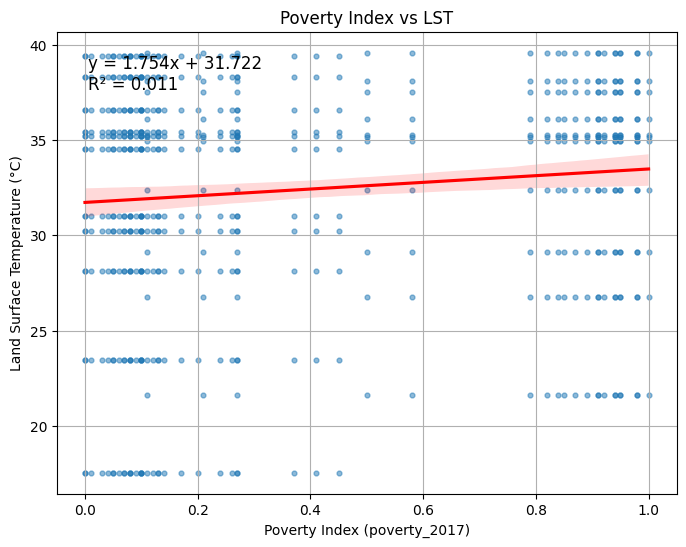

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd # Import pandas

# Ensure df3 is in the correct state with poverty data
df3 = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
poverty = pd.read_csv('/content/drive/MyDrive/Dhaka_Poverty_2017.csv')
poverty.rename(columns={'NB_BUDENS': 'poverty_2017'}, inplace=True)
df3 = df3.merge(poverty[['AL3_NAMEF', 'poverty_2017']], left_on='NAME_3', right_on='AL3_NAMEF', how='left')

# Drop rows with NaN values in 'poverty_2017' or 'LST' for the regression
df_cleaned = df3.dropna(subset=['poverty_2017', 'LST'])

# Extract variables for regression
x = df_cleaned['poverty_2017'].values.reshape(-1, 1)
y = df_cleaned['LST'].values

# Fit regression model
model = LinearRegression().fit(x, y)
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(x, y)

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_cleaned,
    x='poverty_2017',
    y='LST',
    scatter_kws={'s': 12, 'alpha': 0.5},
    line_kws={'color': 'red'}
)

# Add regression equation
plt.text(
    0.05, 0.95,
    f"y = {slope:.3f}x + {intercept:.3f}\nR² = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.title('Poverty Index vs LST')
plt.xlabel('Poverty Index (poverty_2017)')
plt.ylabel('Land Surface Temperature (°C)')
plt.grid(True)
plt.show()

In [ ]:
import altair as alt
import pandas as pd

# Aggregate the LST data by year to show annual trends
annual_lst_summary = df_filtered.groupby('Year').agg(
    MeanLST_mean=('MeanLST', 'mean'),
    MinLST_mean=('MinLST', 'mean'),
    MaxLST_mean=('MaxLST', 'mean')
).reset_index()

# Melt the DataFrame for Altair to easily plot multiple lines
df_melted_annual = annual_lst_summary.melt(
    id_vars=['Year'],
    value_vars=['MeanLST_mean', 'MinLST_mean', 'MaxLST_mean'],
    var_name='LST Type',
    value_name='Temperature'
)

# Create the interactive Altair chart
chart = alt.Chart(df_melted_annual).mark_line(point=True).encode(
    x=alt.X('Year:O', title='Year'),
    y=alt.Y('Temperature:Q', title='LST (°C)'),
    color=alt.Color('LST Type:N', title='LST Type', scale=alt.Scale(
        domain=['MinLST_mean', 'MeanLST_mean', 'MaxLST_mean'],
        range=['blue', 'red', 'orange']
    )),
    tooltip=['Year:O', alt.Tooltip('Temperature:Q', format='.2f', title='Temperature'), 'LST Type:N']
).properties(
    title='Annual LST Trends (2014-2024)',
    width=700,
    height=400
).interactive()

chart

alt.Chart(...)

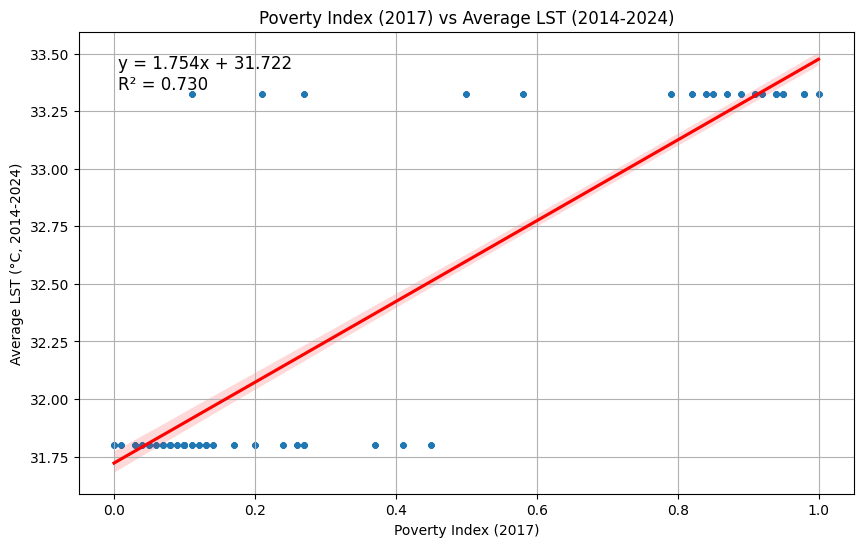

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Ensure df3 is in the correct state with poverty data and mean_LST_2014_2024
# Re-loading df3 and merging poverty to ensure consistency in this execution block
df3 = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
poverty = pd.read_csv('/content/drive/MyDrive/Dhaka_Poverty_2017.csv')
poverty.rename(columns={'NB_BUDENS': 'poverty_2017'}, inplace=True)
df3 = df3.merge(poverty[['AL3_NAMEF', 'poverty_2017']], left_on='NAME_3', right_on='AL3_NAMEF', how='left')

# Calculate mean LST for each NAME_3 if not already present or to ensure consistency
mean_lst = df3.groupby('NAME_3')['LST'].mean().reset_index()
mean_lst.rename(columns={'LST': 'mean_LST_2014_2024'}, inplace=True)
df3 = df3.merge(mean_lst, on='NAME_3', how='left')

# Create a cleaned DataFrame for the plot, ensuring no NaNs in the relevant columns
df_cleaned_for_plot = df3.dropna(subset=['poverty_2017', 'mean_LST_2014_2024'])

# Extract variables for regression
x = df_cleaned_for_plot['poverty_2017'].values.reshape(-1, 1)
y = df_cleaned_for_plot['mean_LST_2014_2024'].values

# Fit regression model
model = LinearRegression().fit(x, y)
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(x, y)

# Plot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_cleaned_for_plot,
    x='poverty_2017',
    y='mean_LST_2014_2024',
    scatter_kws={'s': 12, 'alpha': 0.5},
    line_kws={'color': 'red'}
)

# Add regression equation
plt.text(
    0.05, 0.95,
    f"y = {slope:.3f}x + {intercept:.3f}\nR² = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.title('Poverty Index (2017) vs Average LST (2014-2024)')
plt.xlabel('Poverty Index (2017)')
plt.ylabel('Average LST (°C, 2014-2024)')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# Ensure df3 is loaded and necessary columns are numeric
# (Assuming df3 is already loaded and processed with LST, NDVI, NDBI, MNDWI from previous cells or re-load here for robustness)
df3 = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
df3["NDVI"] = pd.to_numeric(df3["NDVI"], errors='coerce')
df3["NDBI"] = pd.to_numeric(df3["NDBI"], errors='coerce')
df3["MNDWI"] = pd.to_numeric(df3["MNDWI"], errors='coerce')
df3["LST"] = pd.to_numeric(df3["LST"], errors='coerce')

# Compute IBI (if not already computed and needed for correlation matrix)
df3["IBI"] = (df3["NDBI"] - (df3["NDVI"] + df3["MNDWI"])) / \
             (df3["NDBI"] + (df3["NDVI"] + df3["MNDWI"])) # Calculate IBI using numeric values

# Drop rows with missing values that might affect correlation calculation
df3_cleaned_for_corr = df3.dropna(subset=["NDVI", "NDBI", "MNDWI", "LST", "IBI"])

# Apply LST threshold (as previously defined)
df3_cleaned_for_corr = df3_cleaned_for_corr[df3_cleaned_for_corr["LST"] >= 20]

# Calculate correlations as done in the original deleted cell
dfndvi = df3_cleaned_for_corr[df3_cleaned_for_corr["NDVI"] >= 0.2]
dfmndwi = df3_cleaned_for_corr[df3_cleaned_for_corr["NDVI"] < 0.2]

cor_LST_NDVI = dfndvi[['LST', 'NDVI']].corr().loc['LST', 'NDVI']
cor_LST_MNDWI = dfmndwi[['LST', 'MNDWI']].corr().loc['LST', 'MNDWI']
cor_LST_IBI = df3_cleaned_for_corr[['LST', 'IBI']].corr().loc['LST', 'IBI']
cor_NDVI_IBI = df3_cleaned_for_corr[['NDVI', 'IBI']].corr().loc['NDVI', 'IBI']
cor_NDVI_MNDWI = df3_cleaned_for_corr[['NDVI', 'MNDWI']].corr().loc['NDVI', 'MNDWI']
cor_IBI_MNDWI = df3_cleaned_for_corr[['IBI', 'MNDWI']].corr().loc['IBI', 'MNDWI']

cor_matrix = pd.DataFrame({
    'LST':   [1, cor_LST_NDVI, cor_LST_IBI, cor_LST_MNDWI],
    'NDVI':  [cor_LST_NDVI, 1, cor_NDVI_IBI, cor_NDVI_MNDWI],
    'IBI':   [cor_LST_IBI, cor_NDVI_IBI, 1, cor_IBI_MNDWI],
    'MNDWI': [cor_LST_MNDWI, cor_NDVI_MNDWI, cor_IBI_MNDWI, 1]
}, index=['LST', 'NDVI', 'IBI', 'MNDWI'])

print("Combined Correlation Matrix:")
display(cor_matrix)


In [ ]:
display(df_cleaned_for_plot.describe())

In [ ]:
print("First 5 rows of the poverty DataFrame:")
display(poverty.head())

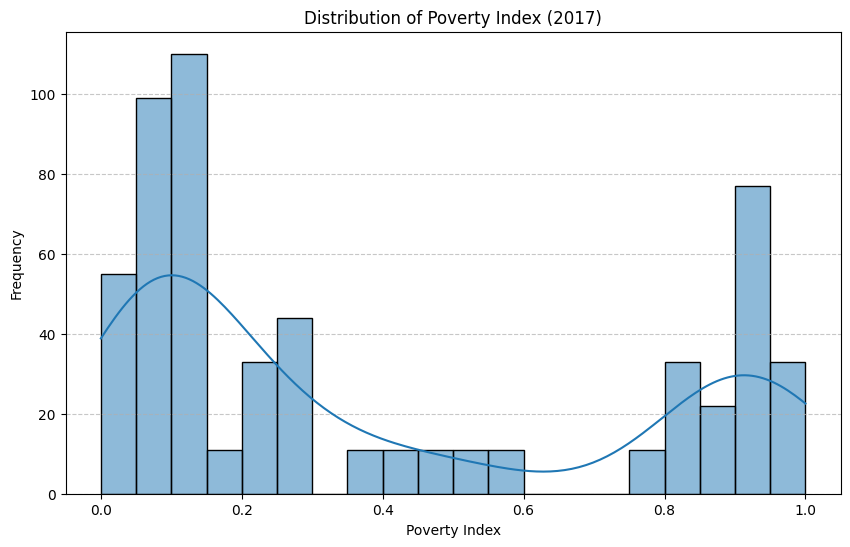

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_cleaned_for_plot contains the 'poverty_2017' column after dropping NaNs
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned_for_plot['poverty_2017'], kde=True, bins=20)
plt.title('Distribution of Poverty Index (2017)')
plt.xlabel('Poverty Index')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

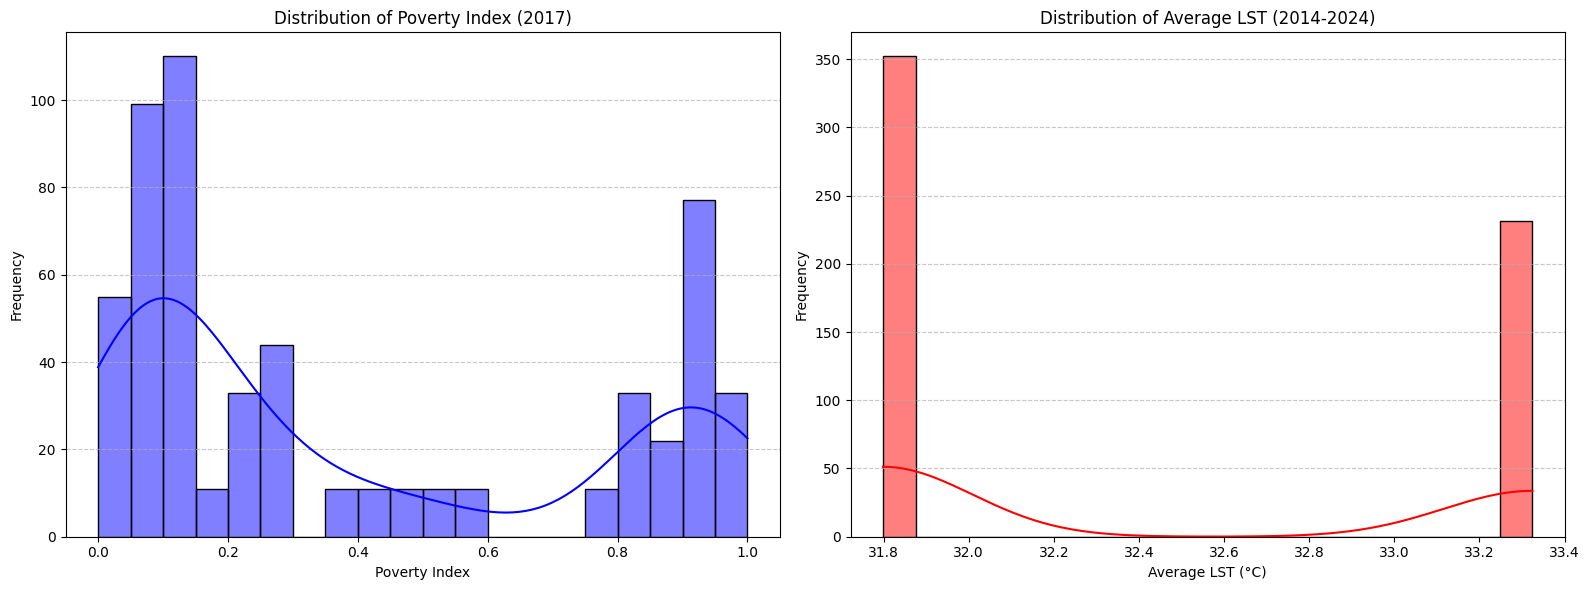

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot distribution of poverty_2017
sns.histplot(df_cleaned_for_plot['poverty_2017'], kde=True, bins=20, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Poverty Index (2017)')
axes[0].set_xlabel('Poverty Index')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot distribution of mean_LST_2014_2024
sns.histplot(df_cleaned_for_plot['mean_LST_2014_2024'], kde=True, bins=20, ax=axes[1], color='red')
axes[1].set_title('Distribution of Average LST (2014-2024)')
axes[1].set_xlabel('Average LST (°C)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

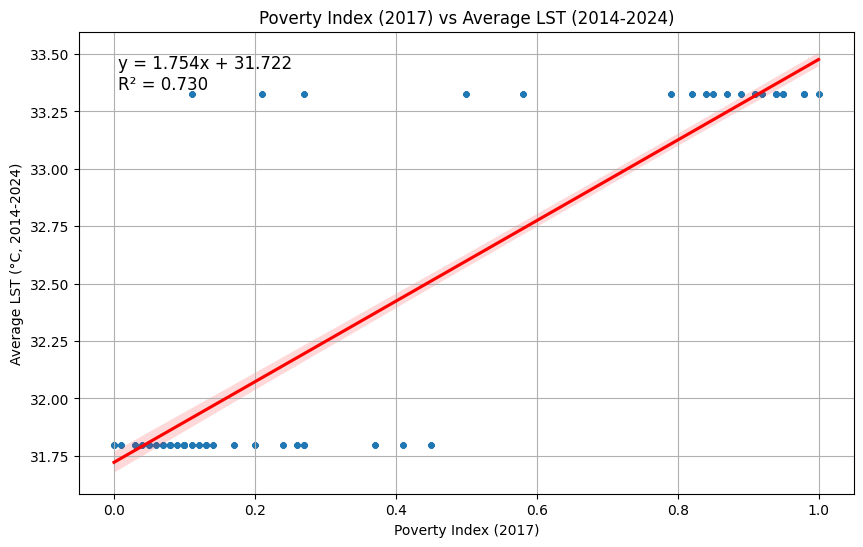

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Ensure df3 is in the correct state with poverty data and mean_LST_2014_2024
# Re-loading df3 and merging poverty to ensure consistency in this execution block
df3 = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
poverty = pd.read_csv('/content/drive/MyDrive/Dhaka_Poverty_2017.csv')
poverty.rename(columns={'NB_BUDENS': 'poverty_2017'}, inplace=True)
df3 = df3.merge(poverty[['AL3_NAMEF', 'poverty_2017']], left_on='NAME_3', right_on='AL3_NAMEF', how='left')

# Calculate mean LST for each NAME_3 if not already present or to ensure consistency
mean_lst = df3.groupby('NAME_3')['LST'].mean().reset_index()
mean_lst.rename(columns={'LST': 'mean_LST_2014_2024'}, inplace=True)
df3 = df3.merge(mean_lst, on='NAME_3', how='left')

# Create a cleaned DataFrame for the plot, ensuring no NaNs in the relevant columns
df_cleaned_for_plot = df3.dropna(subset=['poverty_2017', 'mean_LST_2014_2024'])

# Extract variables for regression
x = df_cleaned_for_plot['poverty_2017'].values.reshape(-1, 1)
y = df_cleaned_for_plot['mean_LST_2014_2024'].values

# Fit regression model
model = LinearRegression().fit(x, y)
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(x, y)

# Plot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_cleaned_for_plot,
    x='poverty_2017',
    y='mean_LST_2014_2024',
    scatter_kws={'s': 12, 'alpha': 0.5},
    line_kws={'color': 'red'}
)

# Add regression equation
plt.text(
    0.05, 0.95,
    f"y = {slope:.3f}x + {intercept:.3f}\nR² = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.title('Poverty Index (2017) vs Average LST (2014-2024)')
plt.xlabel('Poverty Index (2017)')
plt.ylabel('Average LST (°C, 2014-2024)')
plt.grid(True)
plt.show()

In [ ]:
print("Info on the poverty DataFrame (columns, non-null count, and data types):")
poverty.info()

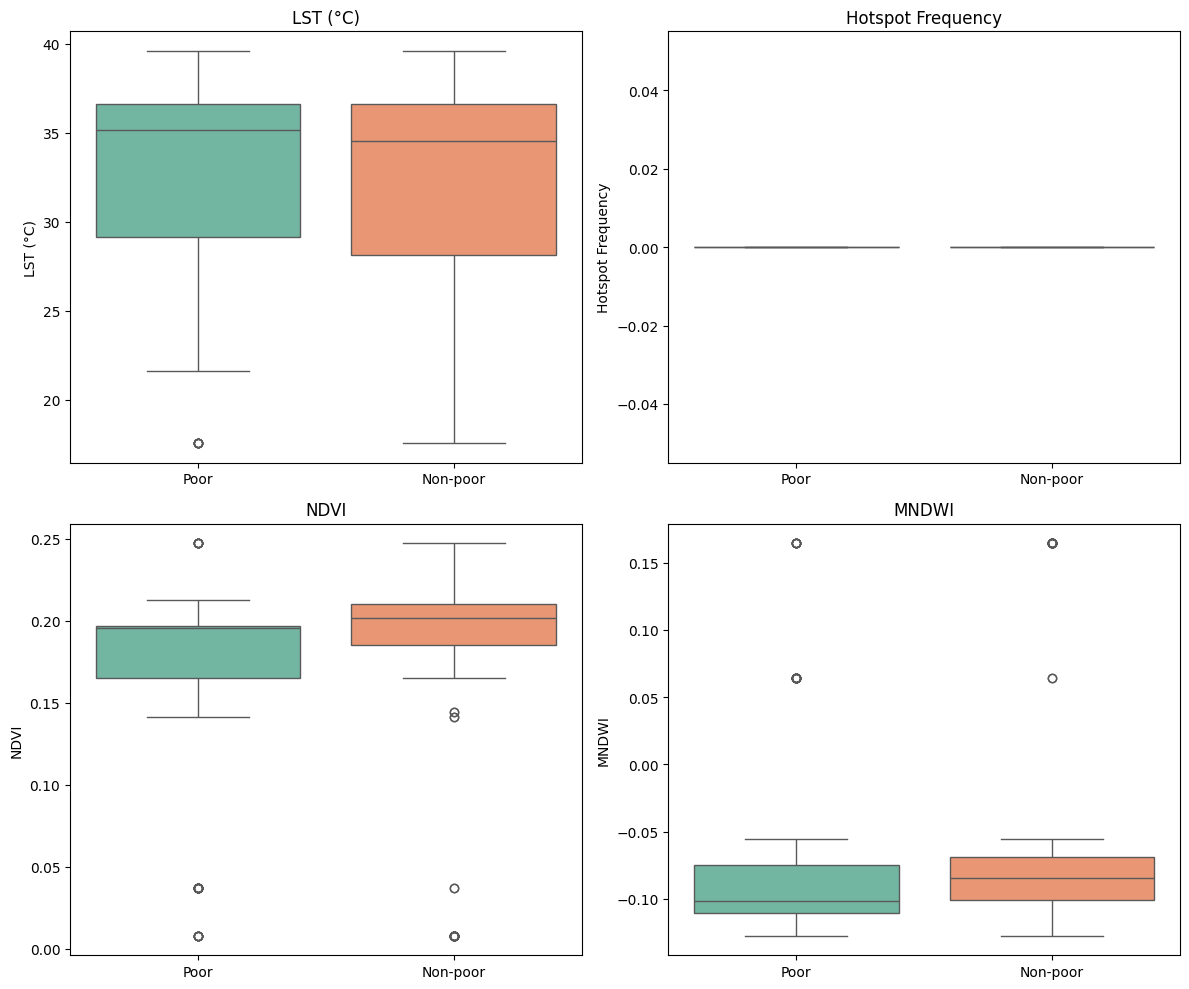

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Re-load df3 and re-apply transformations to ensure columns are present ---
# This is necessary because df3 might have been reset by other cells
df3 = pd.read_csv('/content/drive/MyDrive/Dhaka_Correlation/Dhaka_Correlation_2014_2024.csv')
poverty = pd.read_csv('/content/drive/MyDrive/Dhaka_Poverty_2017.csv')
poverty.rename(columns={'NB_BUDENS': 'poverty_2017'}, inplace=True)
df3 = df3.merge(poverty[['AL3_NAMEF', 'poverty_2017']], left_on='NAME_3', right_on='AL3_NAMEF', how='left')

# Calculate hotspot_freq (code from JsBE8ien0h05)
threshold = df3['LST'].quantile(0.95)
df3['is_hotspot'] = (df3['LST'] >= threshold).astype(int)
hotspot_freq_df = df3.groupby('NAME_3')['is_hotspot'].sum().reset_index()
hotspot_freq_df.rename(columns={'is_hotspot': 'hotspot_freq'}, inplace=True)
df3 = df3.merge(hotspot_freq_df, on='NAME_3', how='left')

# Create a binary poverty class based on building density using 'poverty_2017'
# Ensure df3 is cleaned of NaNs in the relevant columns for robust median calculation
clean_df3 = df3.dropna(subset=['poverty_2017', 'LST', 'hotspot_freq', 'NDVI', 'MNDWI'])

clean_df3['poverty_class'] = clean_df3['poverty_2017'].apply(lambda x: 'Poor' if x > clean_df3['poverty_2017'].median() else 'Non-poor')

variables = ['LST', 'hotspot_freq', 'NDVI', 'MNDWI'] # Corrected 'LST_mean' to 'LST', 'water_share' to 'MNDWI'
titles = ['LST (°C)', 'Hotspot Frequency', 'NDVI', 'MNDWI'] # Updated titles

plt.figure(figsize=(12, 10))

for i, var in enumerate(variables, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=clean_df3, x='poverty_class', y=var, palette='Set2')
    plt.title(titles[i-1])
    plt.xlabel('')
    plt.ylabel(titles[i-1])

plt.tight_layout()
plt.show()

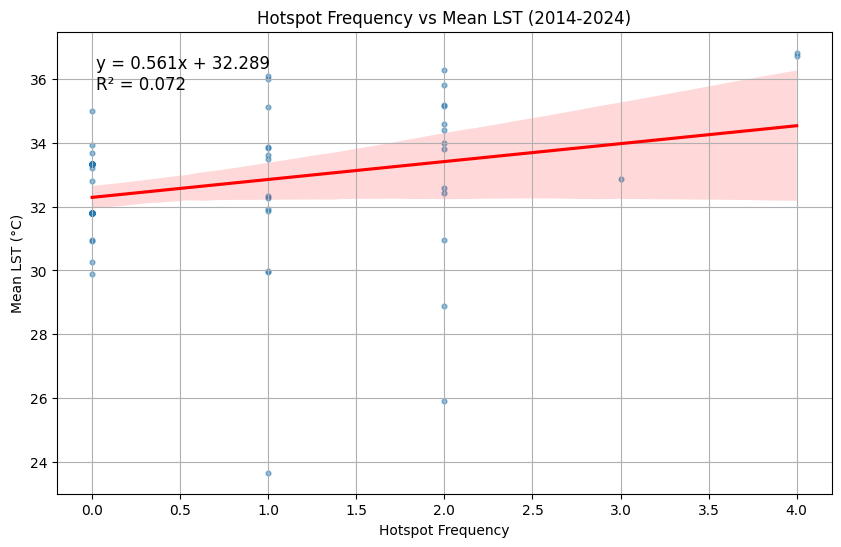

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# Drop rows with NaN values in 'hotspot_freq' or 'mean_LST_2014_2024' for the regression
df_cleaned_for_plot = df_zone.dropna(subset=['hotspot_freq', 'mean_LST_2014_2024'])

x = df_cleaned_for_plot['hotspot_freq'].values.reshape(-1, 1)
y = df_cleaned_for_plot['mean_LST_2014_2024'].values

model = LinearRegression().fit(x, y)
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(x, y)

plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_cleaned_for_plot,
    x='hotspot_freq',
    y='mean_LST_2014_2024',
    scatter_kws={'s': 12, 'alpha': 0.5},
    line_kws={'color': 'red'}
)

plt.text(
    0.05, 0.95,
    f"y = {slope:.3f}x + {intercept:.3f}\nR² = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.title('Hotspot Frequency vs Mean LST (2014-2024)')
plt.xlabel('Hotspot Frequency')
plt.ylabel('Mean LST (°C)')
plt.grid(True)
plt.show()

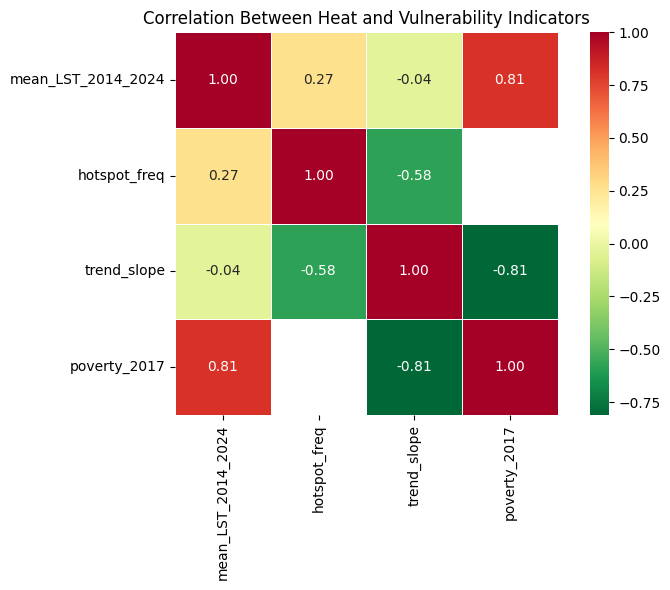

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Select only the variables relevant to high-risk zones
# Use df_zone which contains the aggregated metrics per ward
# ---------------------------------------------------------

corr_vars = [
    'mean_LST_2014_2024', # Corrected to match df_zone column
    'hotspot_freq',    # Corrected to match df_zone column
    'trend_slope',     # Corrected to match df_zone column
    'poverty_2017'     # Corrected to match df_zone column
]

df_corr = df_zone[corr_vars].corr()

# ---------------------------------------------------------
# Plot correlation heatmap
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_corr,
    annot=True,
    cmap='RdYlGn_r',
    linewidths=0.5,
    fmt=".2f",
    square=True
)

plt.title('Correlation Between Heat and Vulnerability Indicators')
plt.tight_layout()
plt.show()

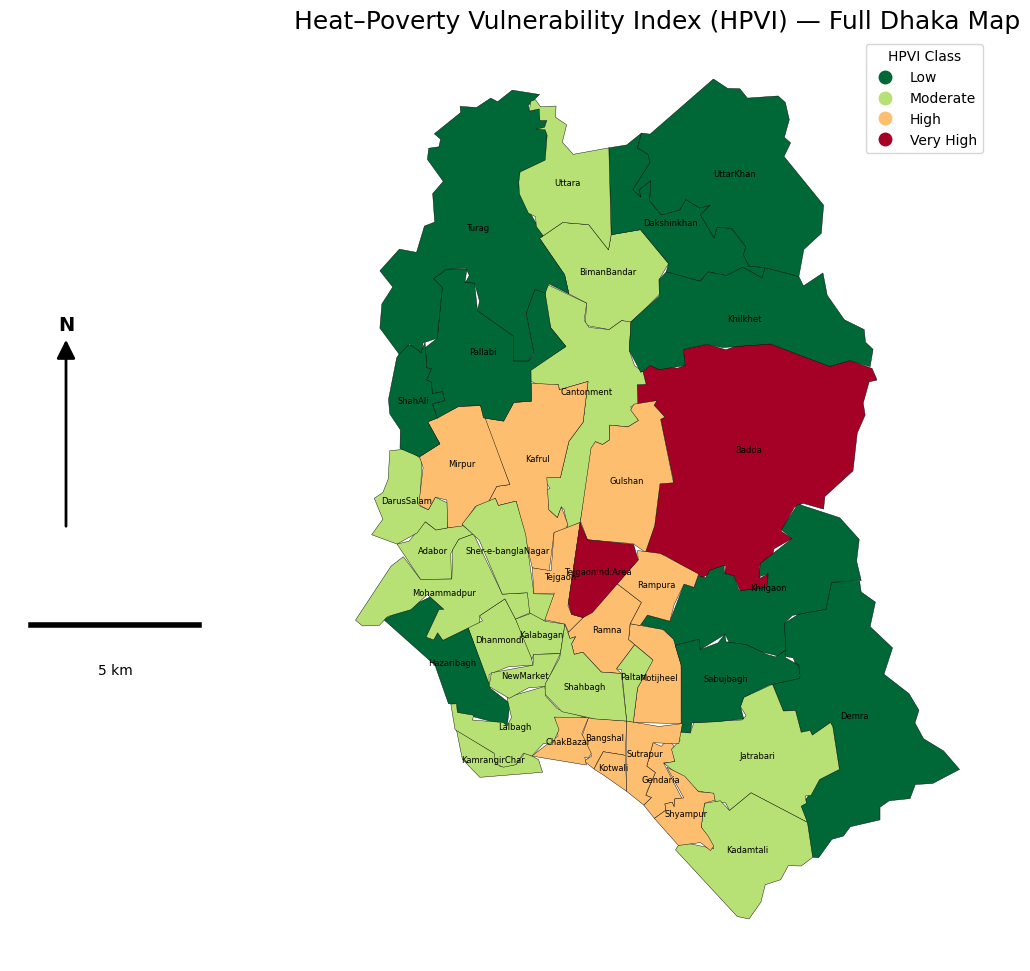

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch

# ---------------------------------------------------------
# 1. Load HPVI CSV
# ---------------------------------------------------------
csv_path = '/content/drive/MyDrive/ARS/Scientific_Project/Dhaka_Heat_Poverty_Vulnerability_Zones.csv'
df_zone = pd.read_csv(csv_path)

df_zone['Heat_z'] = pd.to_numeric(df_zone['Heat_z'], errors='coerce')
df_zone['Poverty_z'] = pd.to_numeric(df_zone['Poverty_z'], errors='coerce')

# HPVI calculation
df_zone['HPVI'] = df_zone['Heat_z'] + df_zone['Poverty_z']

# HPVI class labels
df_zone['HPVI_class'] = pd.cut(
    df_zone['HPVI'],
    bins=[-np.inf, -0.5, 0.5, 1.5, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

# ---------------------------------------------------------
# 2. Load shapefile
# ---------------------------------------------------------
shp_path = '/content/drive/MyDrive/Coredhaka.shp'
wards = gpd.read_file(shp_path)

# ---------------------------------------------------------
# 3. Standardize names for merging
# ---------------------------------------------------------
wards['NAME_3_clean'] = wards['NAME_3'].astype(str).str.strip().str.lower()
df_zone['NAME_3_clean'] = df_zone['NAME_3'].astype(str).str.strip().str.lower()

# ---------------------------------------------------------
# 4. Merge HPVI into shapefile
# ---------------------------------------------------------
wards_hpvi = wards.merge(
    df_zone[['NAME_3_clean', 'HPVI', 'HPVI_class']],
    on='NAME_3_clean',
    how='left'
)

# Create centroids for labeling
wards_hpvi['centroid'] = wards_hpvi.geometry.centroid

# ---------------------------------------------------------
# 5. Plot HPVI map
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

wards_hpvi.plot(
    column='HPVI_class',
    cmap='RdYlGn_r',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    legend_kwds={'title': "HPVI Class"},
    ax=ax
)

# ---------------------------------------------------------
# Add zone names
# ---------------------------------------------------------
for idx, row in wards_hpvi.iterrows():
    if pd.notna(row['NAME_3']):
        ax.text(
            row['centroid'].x,
            row['centroid'].y,
            str(row['NAME_3']),
            fontsize=6,
            ha='center',
            va='center',
            color='black'
        )

# ---------------------------------------------------------
# Add North Arrow (center-left)
# ---------------------------------------------------------
na_ax = fig.add_axes([0.05, 0.45, 0.08, 0.20])  # center-left placement
na_ax.axis("off")

arrow = FancyArrowPatch(
    posA=(0.5, 0.1),
    posB=(0.5, 0.9),
    arrowstyle='-|>',
    mutation_scale=28,
    color='black',
    linewidth=2,
    transform=na_ax.transAxes
)
na_ax.add_patch(arrow)

na_ax.text(
    0.5, 0.95,
    "N",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    transform=na_ax.transAxes
)

# ---------------------------------------------------------
# Add 5 km Scale Bar (center-left, below arrow)
# ---------------------------------------------------------
meters_per_degree_lat = 110574  # Dhaka latitude ≈ 23.8°
deg_for_5km = 5000 / meters_per_degree_lat

sb_ax = fig.add_axes([0.05, 0.35, 0.15, 0.08])  # center-left placement
sb_ax.axis("off")

sb_ax.plot(
    [0.1, 0.9],
    [0.5, 0.5],
    color="black",
    linewidth=4,
    transform=sb_ax.transAxes
)

sb_ax.text(
    0.5, 0.1,
    "5 km",
    ha="center",
    va="top",
    fontsize=10,
    transform=sb_ax.transAxes
)

# ---------------------------------------------------------
# Final layout
# ---------------------------------------------------------
ax.set_title("Heat–Poverty Vulnerability Index (HPVI) — Full Dhaka Map", fontsize=18)
ax.axis('off')

plt.show()
